# Modelling Neurodegeneration with Modern Hopfield Networks

This notebook models the progressive cognitive decline seen in neurodegenerative diseases (e.g. Alzheimer's) using a **Modern Hopfield Network**. Asian country flags serve as memory patterns — the network's ability to retrieve a noisy flag represents a brain's ability to recall a memory.

We simulate three biologically-motivated stages of decline:

| Stage | Biological Basis | Model Mechanism |
|-------|-----------------|------------------|
| **Stage 1** | Astrocyte dysfunction | Glutamate neuromodulation weakens |
| **Stage 2** | Synaptic pruning / loss | Weight matrix scaled down |
| **Stage 3** | Neuronal death | Neurons randomly silenced |

We then run two stress tests:
- **Noise robustness**: how much corruption can the network tolerate at each stage?
- **Capacity**: how many patterns can be stored before retrieval degrades?

In [1]:
# Importing relevant libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import os
import copy

!pip install wget -q
import wget

# Importing Hopfield Network package
if not os.path.exists("hopfield_networks_utils.py"):
    wget.download(
        "https://github.com/TomGeorge1234/HopfieldNetworkTutorial/raw/main/hopfield_networks_utils.py"
    )

from hopfield_networks_utils import *

np.random.seed(42)  

  Preparing metadata (setup.py) ... done


Loaded 50 flags. Shape: (80, 120)
Value range: [-1.00, 1.00]


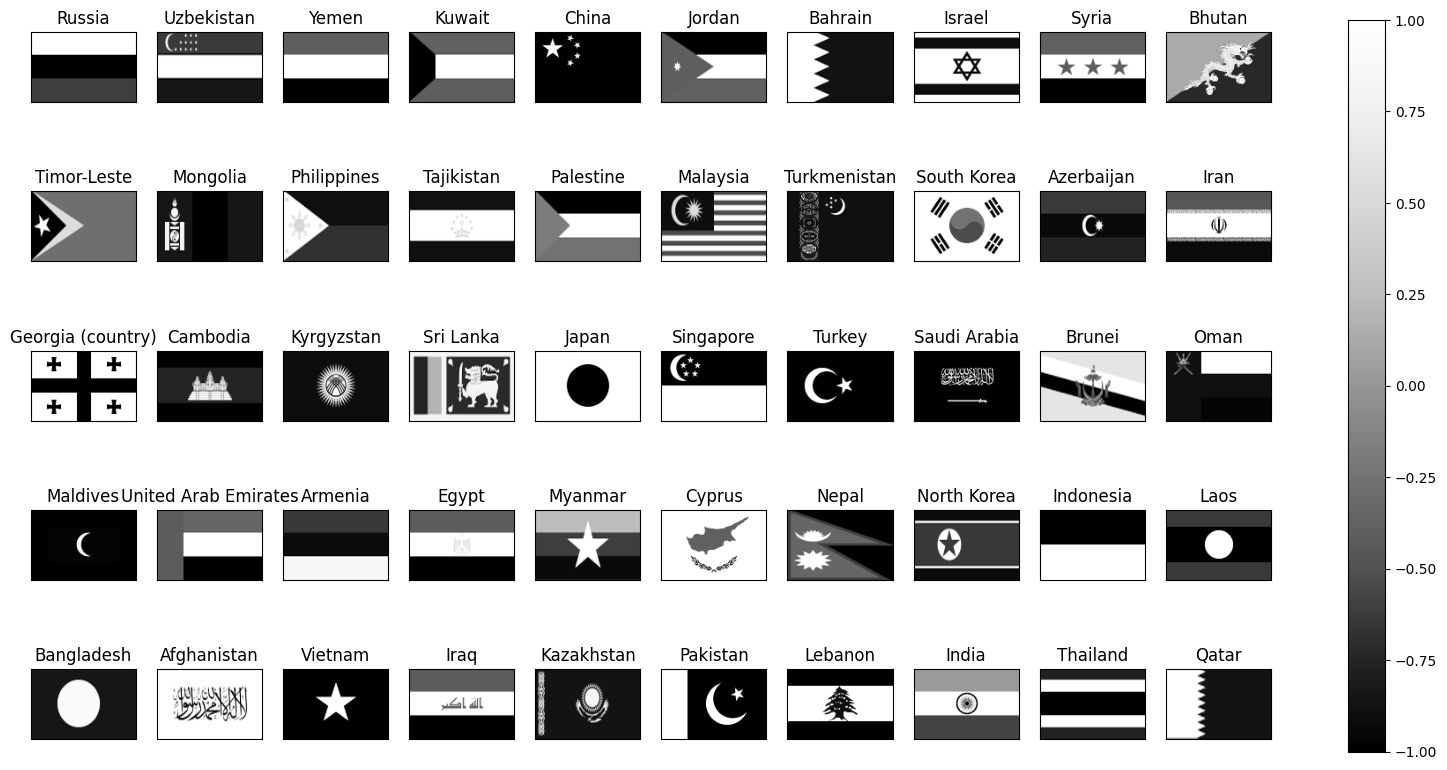

In [2]:
# All the flags of Asia unpacked

file_name = "/kaggle/input/datasets/nmohapatra/flags-of-asia-123/greyscale_images.pickle"

with open(file_name, "rb") as f:
    flags_raw = pickle.load(f)


def scale_array(data, new_min=-1.0, new_max=1.0):
    """Scale array to [new_min, new_max]. Returns zeros if array is constant."""
    old_min, old_max = data.min(), data.max()
    if np.isclose(old_min, old_max):
        return np.zeros_like(data)
    return (data - old_min) / (old_max - old_min) * (new_max - new_min) + new_min


flags_raw = {k: scale_array(np.array(v)) for k, v in flags_raw.items()}

# Sanity check
for k, v in flags_raw.items():
    assert v.min() >= -1.0 and v.max() <= 1.0, f"Scaling failed for {k}"
print(f"Loaded {len(flags_raw)} flags. Shape: {next(iter(flags_raw.values())).shape}")
print(f"Value range: [{next(iter(flags_raw.values())).min():.2f}, {next(iter(flags_raw.values())).max():.2f}]")

plot_patterns(flags_raw);

## 2. Model Definition

### 2.1 Core Utilities

In [3]:
# Softmax function
def stable_softmax(x):
    """Numerically stable softmax."""
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

# Function for adding noise 
def add_noise(pattern, flip_frac=0.1, rng=None):
    """Flip a fraction of pixel signs to simulate a corrupted/partial cue."""
    rng = np.random.default_rng() if rng is None else rng
    flat = pattern.reshape(-1).copy()
    idx = rng.choice(flat.size, size=int(flip_frac * flat.size), replace=False)
    flat[idx] *= -1
    return flat.reshape(pattern.shape)

### 2.2 Modern Hopfield Network with Disease Progression

The network extends a base Modern Hopfield Network with three pathological mechanisms:

**Glutamate dynamics (Stage 1):**
$$\frac{dg}{dt} = \alpha \cdot \bar{|s|} - \gamma \cdot a_{\text{astro}} \cdot g$$

where $g$ is glutamate concentration, $\bar{|s|}$ is mean neural activity, and $a_{\text{astro}}$ is astrocyte function (declines in Stage 1).

**Energy function:**
$$E = -\text{lse}(\beta, \Xi^\top s) + \frac{1}{2} s^\top s$$

where $\text{lse}$ is the log-sum-exp function and $\Xi$ is the memory matrix.

In [4]:
# Defining Modern Hopfield Network 
class ModernHopfieldDisease(BaseHopfieldNetwork):
    """
    Modern Hopfield Network with three neurodegenerative disease stages:
      Stage 1 - Astrocyte decline -> glutamate dysregulation
      Stage 2 - Synaptic loss     -> scaled weight matrix
      Stage 3 - Neuronal death    -> masked/silenced neurons
    """

    def __init__(self, patterns, beta=0.05, eta=0.1, g0=1.0,
                 alpha=1e-1, gamma=1e-6, astro_a=1.0, dt=1.0):

        self.memory_patterns = None  
        self.beta = beta
        self.eta = eta

        super().__init__(patterns)

        self.N_neurons = self.patterns[0].size
        self.neuron_mask = np.ones(self.N_neurons)
        self.synapse_scale = 1.0

        # Glutamate state
        self.g = g0
        self.alpha = alpha
        self.gamma = gamma
        self.astro_a = astro_a
        self.dt = dt
        self.g_history = [self.g]

        # Store clean memory patterns (flattened)
        self.memory_patterns = self.flattened_patterns.copy()

    # ------------------------------------------------------------------
    def update_state(self, use_glutamate=False):
        """One synchronous update step."""

        # 1. Effective memory matrix (apply structural damage)
        patterns = self.memory_patterns * self.synapse_scale
        patterns = patterns * self.neuron_mask[np.newaxis, :]

        # 2. Similarity between state and each memory
        similarity = patterns @ self.state

        # 3. Softmax activation (glutamate sharpens beta)
        beta_eff = self.beta * self.g if use_glutamate else self.beta
        activated = stable_softmax(beta_eff * similarity)

        # 4. State update
        delta = patterns.T @ activated - self.state
        step_size = self.eta * self.g if use_glutamate else self.eta
        self.state += step_size * delta

        # 5. Enforce neuron silencing
        self.state *= self.neuron_mask

        # 6. Glutamate ODE (only when enabled)
        if use_glutamate:
            activity = np.mean(np.abs(self.state))
            dg = self.dt * (self.alpha * activity - self.gamma * self.astro_a * self.g)
            self.g += dg
            self.g_history.append(self.g) 

        # 7. Tracking
        self.energy = self.get_energy()
        self.save_history()

    # ------------------------------------------------------------------
    def get_energy(self, state=None):
        state = self.state if state is None else state
        patterns = (
            self.flattened_patterns if self.memory_patterns is None
            else self.memory_patterns
        )
        sim = patterns @ state
        return -log_sum_exp(sim, beta=self.beta) + 0.5 * state @ state

    '''# ------------------------------------------------------------------
    def apply_synapse_loss(self, target_scale, rng=None, compensate=True):
        """
        Set synapse density to target_scale (absolute, not multiplicative).
        Homeostatic compensation scales up by 1/sqrt(target_scale) to
        partially offset the information loss.
        """
        rng = np.random.default_rng() if rng is None else rng
        self.synapse_scale = target_scale
    
        # Corrupts the memory patterns directly 
        keep_mask = (rng.random(self.memory_patterns.shape) < target_scale).astype(float)
        self.memory_patterns = self.flattened_patterns.copy() * keep_mask'''

    # ------------------------------------------------------------------
    def apply_neuron_deletion(self, keep_prob, rng=None):
        """
        Randomly silence neurons. Highly active neurons are more vulnerable
        (excitotoxicity model): higher activity -> higher deletion probability.
        """
        rng = np.random.default_rng() if rng is None else rng

        activity = np.abs(self.state)
        max_act = np.max(activity)

        if max_act > 1e-8:
            bias = activity / (max_act + 1e-8)
            
            # Survival probability decreases with activity
            prob = keep_prob * (1.0 - bias) + keep_prob * bias * 0.5
            prob = np.clip(prob, 0.0, 1.0)
        else:
            prob = np.full(self.N_neurons, keep_prob)

        mask = (rng.random(self.N_neurons) < prob).astype(float)
        self.neuron_mask *= mask
        self.state *= self.neuron_mask

## 3. Experiment Runner

In [5]:
def run_progression_experiment(
    patterns,
    init_pattern,
    n_steps_1=50, n_steps_2=50, n_steps_3=50,
    flip_frac=0.4,
    final_syn_keep=0.7,
    final_neuron_keep=0.7,
    stage_1=False, stage_2=False, stage_3=False,
):
    """
    Run a staged neurodegeneration experiment.

    Parameters
    ----------
    patterns      : dict of {name: ndarray} memory patterns
    init_pattern  : key of the pattern to use as the retrieval cue
    stage_*       : enable/disable each disease stage
    flip_frac     : fraction of pixels flipped in the noisy initial cue
    final_syn_keep: target synapse density at end of Stage 2 (0-1)
    final_neuron_keep: target neuron survival rate at end of Stage 3 (0-1)

    Returns
    -------
    net  : trained ModernHopfieldDisease instance
    logs : dict of per-step diagnostics
    """
    net = ModernHopfieldDisease(patterns)

    noisy = add_noise(patterns[init_pattern], flip_frac=flip_frac)
    net.set_state(noisy, random=False)

    target_idx = list(patterns.keys()).index(init_pattern)
                                             
    logs = {
        "energy": [], "similarities": [], "g": [],
        "stage": [], "synapse_density": [], "neuron_density": [],
    }

    def _record(stage_id):
        logs["stage"].append(stage_id)
        logs["energy"].append(net.energy)
        logs["similarities"].append(net.get_similarities()[target_idx]) 
        logs["g"].append(net.g)
        logs["synapse_density"].append(net.synapse_scale)
        logs["neuron_density"].append(np.mean(net.neuron_mask))

    # ---------- Healthy baseline (no stages selected) ----------
    if not any([stage_1, stage_2, stage_3]):
        for _ in range(50):
            net.update_state()
            _record(0)

    # ---------- Stage 1: Astrocyte / glutamate decline ----------
    if stage_1:
        for t in range(n_steps_1):
            net.astro_a = 1.0 - 0.7 * (t / n_steps_1)
            net.update_state(use_glutamate=True)
            _record(1)

    # ---------- Stage 2: Synapse loss ----------
    if stage_2:
        rng = np.random.default_rng()

        for t in range(n_steps_2):
            frac = t / n_steps_2
            keep = 1.0 - (1.0 - final_syn_keep) * frac

            keep_mask = (rng.random(net.flattened_patterns.shape) < keep).astype(float)

            net.memory_patterns = net.flattened_patterns.copy() * keep_mask

            # Compensation
            if keep > 1e-8:
                net.memory_patterns *= 1.0 / np.sqrt(keep)

            net.update_state()
            _record(2)

    # ---------- Stage 3: Neuron loss ----------
    if stage_3:
        initial_mask = net.neuron_mask.copy()
        for t in range(n_steps_3):
            keep = 1.0 - (1.0 - final_neuron_keep) * (t / n_steps_3)
            net.neuron_mask = initial_mask.copy()
            net.apply_neuron_deletion(keep_prob=keep)
            net.update_state()
            _record(3)

    return net, logs

## 4. Disease Progression: Single-Flag Visualisation

We run Malaysia through each stage cumulatively and visualise energy and final retrieved state.


  Healthy
  Final energy:     -4738.1680
  Final similarity: 0.8995
  Synapse density:  1.0000
  Neuron density:   1.0000
n_steps: None
n_steps: 50


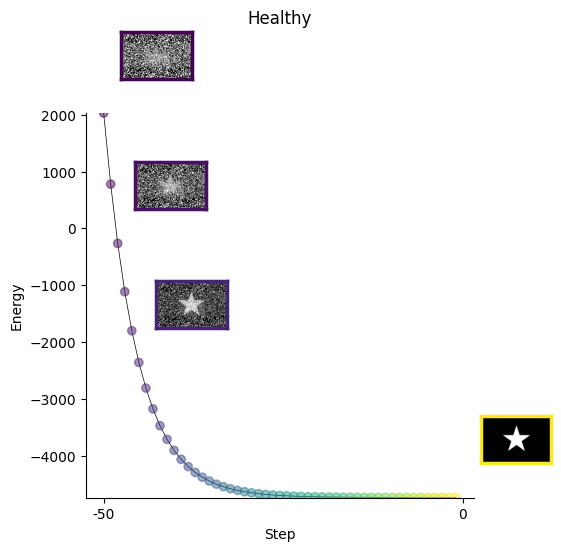

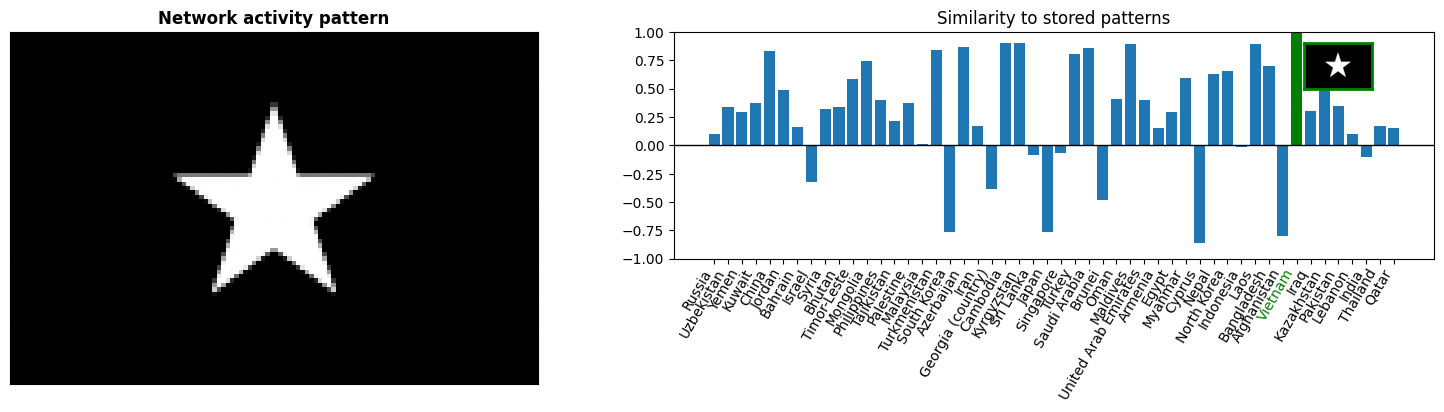


  Stage 1: Astrocyte decline
  Final energy:     -4738.3490
  Final similarity: 0.8994
  Synapse density:  1.0000
  Neuron density:   1.0000
n_steps: None
n_steps: 50


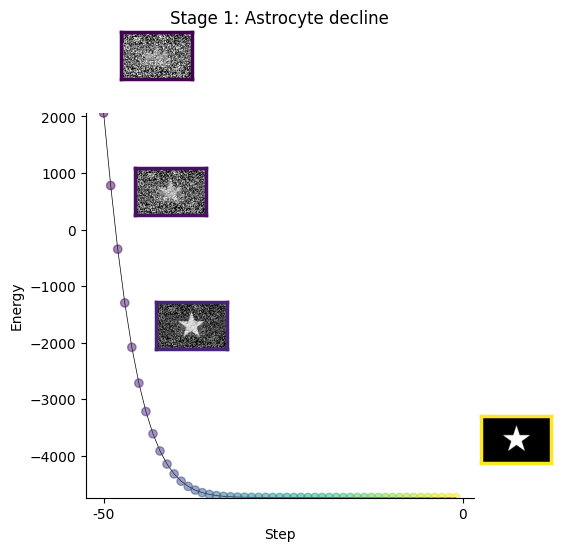

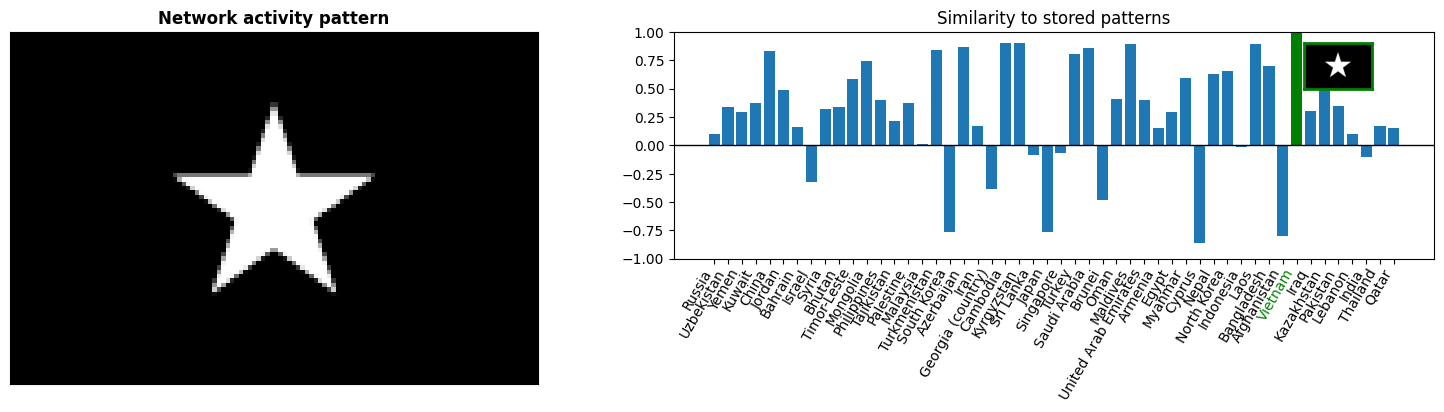


  Stage 2: Synapse loss
  Final energy:     -3507.5590
  Final similarity: 0.8911
  Synapse density:  1.0000
  Neuron density:   1.0000
n_steps: None
n_steps: 100


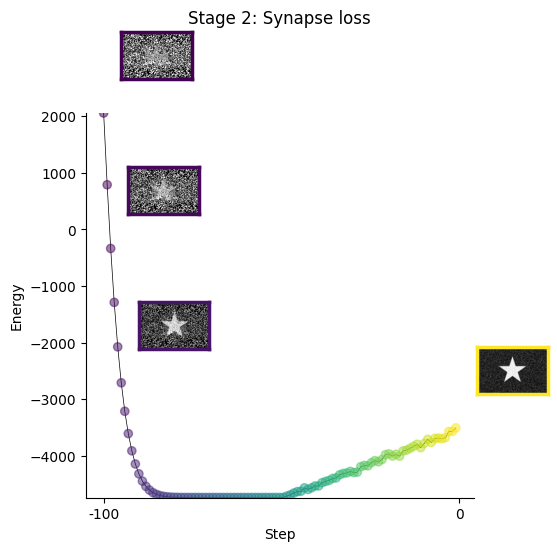

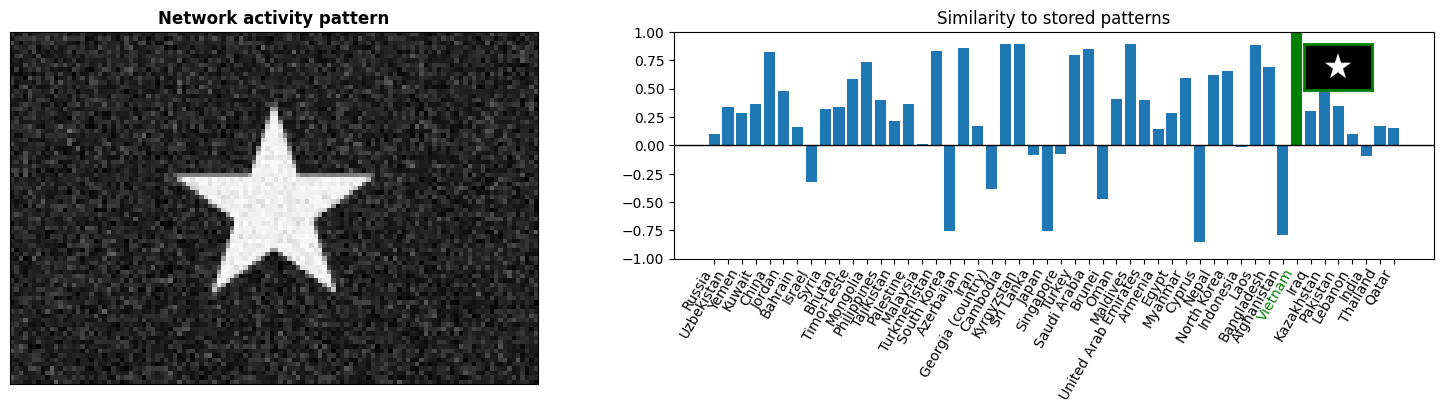


  Stage 3: Neuron death
  Final energy:     -1087.0751
  Final similarity: 0.5224
  Synapse density:  1.0000
  Neuron density:   0.6626
n_steps: None
n_steps: 150


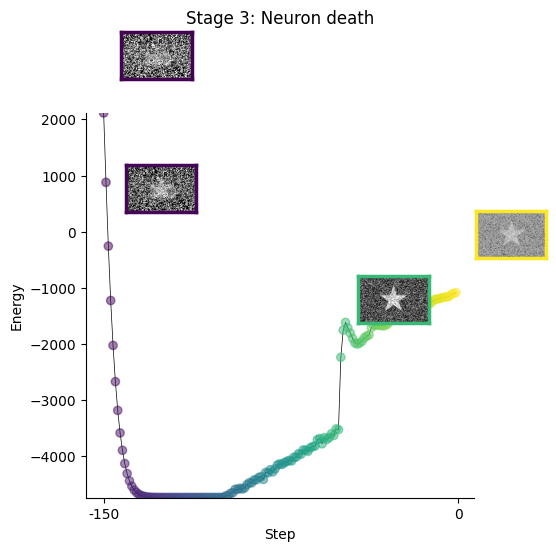

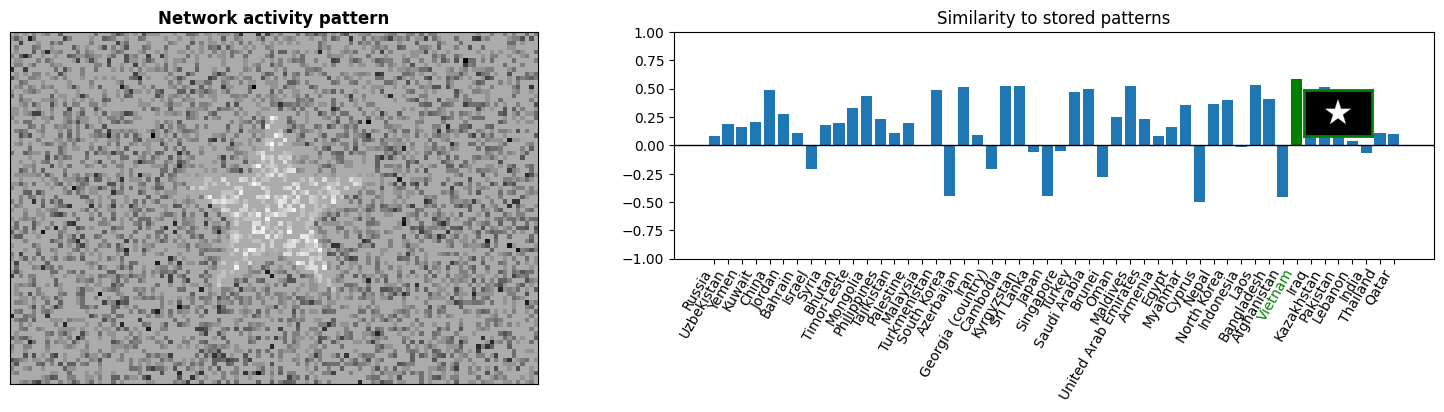

In [6]:
# Showing the progression of energy plots across stages

TARGET_FLAG = "Cambodia"
stage_configs = [
    dict(label="Healthy",                    stage_1=False, stage_2=False, stage_3=False),
    dict(label="Stage 1: Astrocyte decline", stage_1=True,  stage_2=False, stage_3=False),
    dict(label="Stage 2: Synapse loss",      stage_1=True,  stage_2=True,  stage_3=False),
    dict(label="Stage 3: Neuron death",      stage_1=True,  stage_2=True,  stage_3=True),
]

for cfg in stage_configs:
    label = cfg["label"] 
    run_cfg = {k: v for k, v in cfg.items() if k != "label"}  
    
    flags = copy.deepcopy(flags_raw)
    net, logs = run_progression_experiment(
        flags, TARGET_FLAG,
        n_steps_1=50, n_steps_2=50, n_steps_3=50,
        **run_cfg
    )
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"  Final energy:     {logs['energy'][-1]:.4f}")
    print(f"  Final similarity: {logs['similarities'][-1].max():.4f}")
    print(f"  Synapse density:  {logs['synapse_density'][-1]:.4f}")
    print(f"  Neuron density:   {logs['neuron_density'][-1]:.4f}")
    net.plot_energy()
    plt.title(label)
    plt.show()
    net.visualise()
    plt.show()

## 5. Noise Robustness Stress Test

We vary the fraction of corrupted pixels in the initial cue (0.1 → 0.9) and measure the final similarity to the target flag. This tests how robust memory retrieval is under each disease stage.

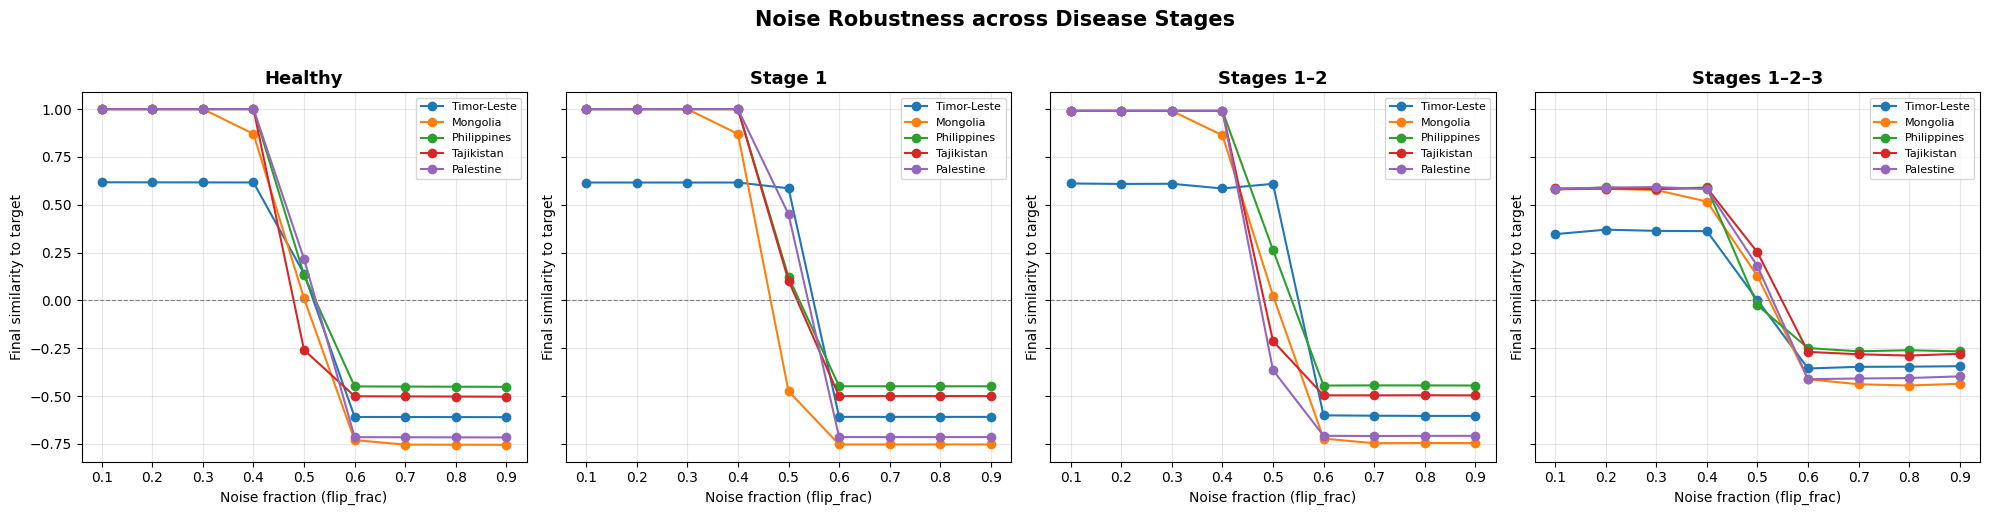

In [7]:
# Testing the noise level each stage can handle
def stress_test(target_flag, all_flags, stage_1=False, stage_2=False, stage_3=False):
    """
    Sweep noise levels and record final target similarity at each level.

    Parameters
    ----------
    target_flag : str  — flag to retrieve
    all_flags   : dict — clean copy of the full flag set (not mutated)

    Returns
    -------
    dict {flip_frac: final_similarity}
    """
    target_idx = list(all_flags.keys()).index(target_flag)
    results = {}

    for flip_frac in np.arange(0.1, 1.0, 0.1):
        flags = copy.deepcopy(all_flags)  # fresh copy every run
        _, logs = run_progression_experiment(
            flags, target_flag,
            flip_frac=round(float(flip_frac), 1),
            stage_1=stage_1, stage_2=stage_2, stage_3=stage_3,
        )
        results[flip_frac] = logs["similarities"][-1]

    return results


COUNTRIES = list(flags_raw.keys())[10:15]
stress_configs = [
    dict(label="Healthy",         stage_1=False, stage_2=False, stage_3=False),
    dict(label="Stage 1",         stage_1=True,  stage_2=False, stage_3=False),
    dict(label="Stages 1–2",      stage_1=True,  stage_2=True,  stage_3=False),
    dict(label="Stages 1–2–3",    stage_1=True,  stage_2=True,  stage_3=True),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, cfg in zip(axes, stress_configs):
    label = cfg.pop("label")
    for country in COUNTRIES:
        results = stress_test(country, flags_raw, **cfg)
        x = np.array(list(results.keys()), dtype=float)
        y = np.array(list(results.values()), dtype=float)
        ax.plot(x, y, marker="o", label=country)

    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_xlabel("Noise fraction (flip_frac)")
    ax.set_ylabel("Final similarity to target")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")

fig.suptitle("Noise Robustness across Disease Stages", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 6. Memory Capacity Test

We increase the number of stored patterns from 5 to 50 and measure retrieval similarity to the target. As more patterns are stored, interference increases and retrieval degrades — and the disease stages accelerate this degradation.

  [Healthy] Capacity test: Timor-Leste...
  [Healthy] Capacity test: Mongolia...
  [Healthy] Capacity test: Philippines...
  [Healthy] Capacity test: Tajikistan...
  [Healthy] Capacity test: Palestine...
  [Stage 1] Capacity test: Timor-Leste...
  [Stage 1] Capacity test: Mongolia...
  [Stage 1] Capacity test: Philippines...
  [Stage 1] Capacity test: Tajikistan...
  [Stage 1] Capacity test: Palestine...
  [Stages 1–2] Capacity test: Timor-Leste...
  [Stages 1–2] Capacity test: Mongolia...
  [Stages 1–2] Capacity test: Philippines...
  [Stages 1–2] Capacity test: Tajikistan...
  [Stages 1–2] Capacity test: Palestine...
  [Stages 1–2–3] Capacity test: Timor-Leste...
  [Stages 1–2–3] Capacity test: Mongolia...
  [Stages 1–2–3] Capacity test: Philippines...
  [Stages 1–2–3] Capacity test: Tajikistan...
  [Stages 1–2–3] Capacity test: Palestine...


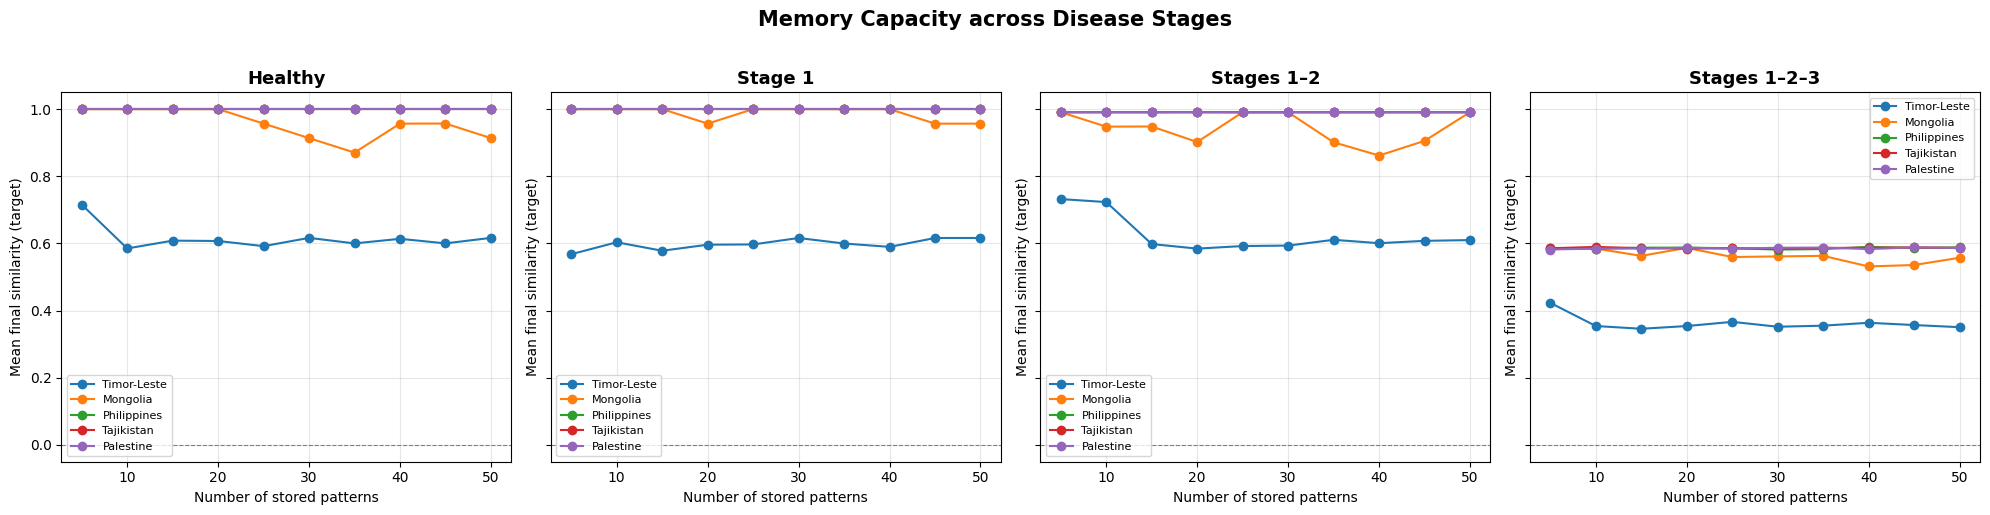

In [8]:
# Analyzing the capacity across stages

def capacity_test(
    target_flag, all_flags, trials=3,
    stage_1=False, stage_2=False, stage_3=False,
    n_steps=50
):
    """
    Measure retrieval similarity as the number of stored patterns increases.

    Parameters
    ----------
    target_flag : str  — flag to retrieve
    all_flags   : dict — clean, unmodified flag set
    trials      : int  — random repetitions per n (averaged)
    n_steps     : int  — update steps per stage (fewer = faster)

    Returns
    -------
    dict {n_patterns: mean_similarity}
    """
    all_keys = list(all_flags.keys())
    distractors = [k for k in all_keys if k != target_flag]
    results = {}

    for n in range(5, 51, 5):
        sims = []
        for _ in range(trials):
            chosen = np.random.choice(distractors, size=n - 1, replace=False)
            subset = {k: all_flags[k] for k in [target_flag] + list(chosen)}

            _, logs = run_progression_experiment(
                subset, target_flag,
                stage_1=stage_1, stage_2=stage_2, stage_3=stage_3,
                n_steps_1=n_steps if stage_1 else 0,
                n_steps_2=n_steps if stage_2 else 0,
                n_steps_3=n_steps if stage_3 else 0,
            )
            sims.append(logs["similarities"][-1])  

        results[n] = float(np.mean(sims))

    return results


capacity_configs = [
    dict(label="Healthy",       stage_1=False, stage_2=False, stage_3=False),
    dict(label="Stage 1",       stage_1=True,  stage_2=False, stage_3=False),
    dict(label="Stages 1–2",    stage_1=True,  stage_2=True,  stage_3=False),
    dict(label="Stages 1–2–3",  stage_1=True,  stage_2=True,  stage_3=True),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, cfg in zip(axes, capacity_configs):
    label = cfg.pop("label")
    for country in COUNTRIES:
        print(f"  [{label}] Capacity test: {country}...")
        results = capacity_test(country, flags_raw, trials=3, **cfg)
        x = np.array(list(results.keys()))
        y = np.array(list(results.values()))
        ax.plot(x, y, marker="o", label=country)

    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of stored patterns")
    ax.set_ylabel("Mean final similarity (target)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")

fig.suptitle("Memory Capacity across Disease Stages", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 7. Glutamate Dynamics Diagnostic

Visualise how glutamate concentration `g` evolves during Stage 1 as astrocyte function declines.

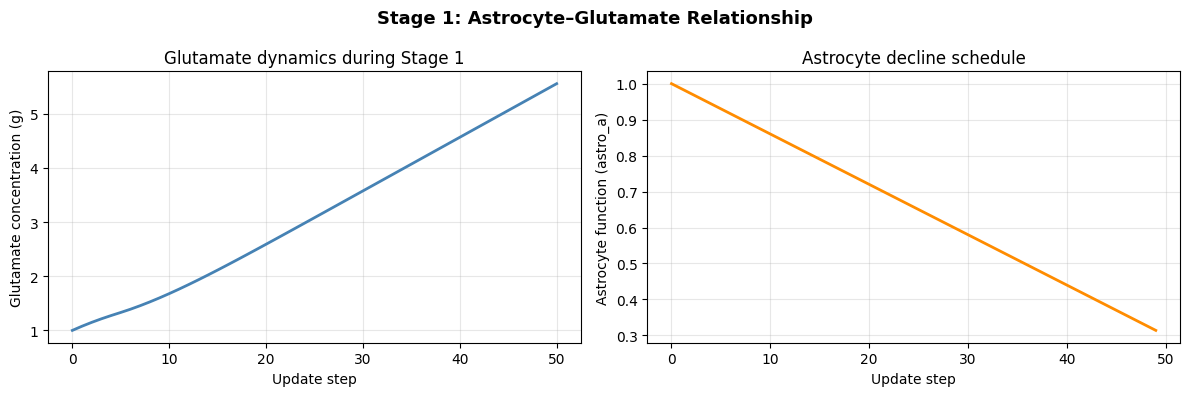

g start: 1.0000
g end:   5.5565
g range: [1.0000, 5.5565]


In [9]:
# Astrocyte activity and glutamate activity relationship is linear

flags = copy.deepcopy(flags_raw)
net, logs = run_progression_experiment(
    flags, TARGET_FLAG, stage_1=True, n_steps_1=50
)

# g_history has one entry per step (appended once in update_state)
assert len(net.g_history) == 51, (
    f"Expected 51 g entries (1 init + 50 steps), got {len(net.g_history)}. "
    "Check for double-appending in update_state / save_history."
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(net.g_history, color="steelblue", linewidth=2)
ax1.set_xlabel("Update step")
ax1.set_ylabel("Glutamate concentration (g)")
ax1.set_title("Glutamate dynamics during Stage 1")
ax1.grid(True, alpha=0.3)

astro_schedule = [1.0 - 0.7 * (t / 50) for t in range(50)]
ax2.plot(astro_schedule, color="darkorange", linewidth=2)
ax2.set_xlabel("Update step")
ax2.set_ylabel("Astrocyte function (astro_a)")
ax2.set_title("Astrocyte decline schedule")
ax2.grid(True, alpha=0.3)

plt.suptitle("Stage 1: Astrocyte–Glutamate Relationship", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"g start: {net.g_history[0]:.4f}")
print(f"g end:   {net.g_history[-1]:.4f}")
print(f"g range: [{min(net.g_history):.4f}, {max(net.g_history):.4f}]")

## 8. Summary

| Experiment | Key Finding |
|------------|-------------|
| **Stage progression** | Energy landscapes become shallower and less stable with each stage |
| **Noise robustness** | The healthy network tolerates ~50% corruption; all stages reduce this threshold |
| **Capacity** | Healthy network retrieves reliably up to ~30 patterns; disease compresses this window |
| **Glutamate dynamics** | With low `gamma`, astrocyte decline has a weak effect on `g` via clearance; the dominant driver is neural activity |

### Design Notes

- **`apply_synapse_loss`** uses an *absolute* target scale (not cumulative multiplication) to avoid compounding collapse over 50 steps.
- **`apply_neuron_deletion`** implements excitotoxicity: more active neurons face higher deletion probability.
- **`g_history`** is appended exactly once per update step to avoid double-counting.
- All flag dicts are deep-copied before each experiment to prevent global mutation across runs.